# Исследование ресторанов Москвы

- Автор: Хабибулина Ю. М.
- Дата: 15.03.2025

### Цели и задачи проекта

Основная цель проекта- изучить рынок заведений Москвы и определить самые востребованную или недостаточно развитую нишу, в которую имеет смысл инвестировать.

Задача проекта- рассмотреть зависимости успеха заведения от его расположения, типа, цен и так далее.

### Описание данных

Два датасета- с общей информацией по заведениям и данными о ценах.

В первом: название заведения, адрес заведения и район, категория, часы работы, рейтинг, количество посадочных мест и информация о том, является ли заведение сетевым.

Во втором: ценовая категория, средние чеки, средняя стоимость чашки кофе.

### Содержимое проекта

После предобработки данных (заполнение пропусков, форматирование), приступила к визуализации данных. Исследовала зависимость разных параметров от категории заведения и района расположения. Так же расммотрела влияние количества посадочных мест на восстребованность заведений. Посмотрела на зависимость рейтинга от разных факторов. Составила топ-15 заведений и оценила их рейтинг, а так же изучила зависимость ценовой политики от расположения.

## 1. Загрузка данных и знакомство с ними


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install phik
import phik
from phik import phik_matrix

  Using cached phik-0.12.4.tar.gz (621 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached scipy-1.15.2-cp313-cp313-macosx_14_0_arm64.whl.metadata (61 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
Using cached scipy-1.15.2-cp313-cp313-macosx_14_0_arm64.whl (22.4 MB)
  error: subprocess-exited-with-error
  
  × Building wheel for phik (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [40 lines of output]
      *** scikit-build-core 0.11.1 using CMake 4.0.0 (wheel)
      *** Configuring CMake...
      loading initial cache file /var/folders/9s/z77wghqj2451bd3rqy3xbcm40000gn/T/tmp0k9i8kui/build/CMakeInit.txt
      -- The CXX compiler identification is unknown
      -- Detecting CXX compiler ABI info
      -- Detecting CXX compiler ABI info - failed
      -- C

ModuleNotFoundError: No module named 'phik'

In [ ]:
info_df = pd.read_csv('/datasets/rest_info.csv')
price_df = pd.read_csv('/datasets/rest_price.csv')

info_df.info()
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   mi

---

### Промежуточный вывод


В датасете с информацией о ресторанах данные о разных заведениях с расположением, информацией о работе, оценки. Пропуски встречаются в полях с часами работы и количеством посадочых мест. В датасете с ценами информация о средних ценах на категории, среднем чеке и цене за чашку капучино. Пропуски во всех столбцах, кроме идентификаторов заведений.

Причем в датасете с ценами указаны данные не обо всех заведениях, а только о половине из датасета с общей информацией. С типами данных, в нем, все в порядке. В датасете с общей информацией число посадочных мест обозначено типом float, хотя это очевидно должен быть int (не может же быть полтора стула).

### Подготовка единого датафрейма

- Объедините данные двух датасетов в один, с которым вы и продолжите работу.

In [ ]:
df = info_df.merge(price_df, on='id', how='outer')
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


## 2. Предобработка данных


Преобразую число посадочных мест в int, пустые значения заменю нулями.

In [ ]:
df['seats'] = np.floor(pd.to_numeric(df['seats'], errors='coerce')).astype('Int64')
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   Int64  
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: Int64(1), float64(3), int64(1), object(8)
memory usage: 927.6+ KB


Проверяю непустые значения:

In [ ]:
missing_abs = (df.isna()).sum()
missing_fract = (missing_abs / len(df)) * 100

result = pd.DataFrame({
    'missing_count': missing_abs,
    'missing_fraction': missing_fract
})

print(result)

                   missing_count  missing_fraction
id                             0          0.000000
name                           0          0.000000
category                       0          0.000000
address                        0          0.000000
district                       0          0.000000
hours                        536          6.376398
rating                         0          0.000000
chain                          0          0.000000
seats                       3611         42.957411
price                       5091         60.563883
avg_bill                    4590         54.603854
middle_avg_bill             5257         62.538663
middle_coffee_cup           7871         93.635498


Пропущенные значения есть в столбце с часами работы, количеством посадочных мест, категорией цен и средними чеками. Так как часы работы представлены строками и количество пропyщенных значений не сильно большое, заменю их на "No information". Пустое количество посадочных мест уже заменила на 0. Пропущенных значений средних чеков слишком много, удалять такое количество данных нельзя, заменять тоже опасно для смещения распредления, поэтому оставлю как есть. 

In [ ]:
df['hours'] = df['hours'].fillna('No information')
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              8406 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   Int64  
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: Int64(1), float64(3), int64(1), object(8)
memory usage: 927.6+ KB


Проверяю данные на дубликаты, но сначала нормализую данные. 

In [ ]:
df['id'] = df['id'].str.lower()
df['name'] = df['name'].str.lower()
df['category'] = df['category'].str.lower()
df['district'] = df['district'].str.lower()
df['hours'] = df['hours'].str.lower()
df['price'] = df['price'].str.lower()
df['avg_bill'] = df['avg_bill'].str.lower()
print(df.head(5))

                                 id                  name  category  \
0  0c3e3439a8c64ea5bf6ecd6ca6ae19f0                wowфли      кафе   
1  045780ada3474c57a2112e505d74b633        четыре комнаты  ресторан   
2  1070b6b59144425896c65889347fcff6                 хазри      кафе   
3  03ac7cd772104f65b58b349dc59f03ee  dormouse coffee shop   кофейня   
4  a163aada139c4c7f87b0b1c0b466a50f             иль марко  пиццерия   

                               address                         district  \
0           Москва, улица Дыбенко, 7/1  северный административный округ   
1   Москва, улица Дыбенко, 36, корп. 1  северный административный округ   
2       Москва, Клязьминская улица, 15  северный административный округ   
3  Москва, улица Маршала Федоренко, 12  северный административный округ   
4      Москва, Правобережная улица, 1Б  северный административный округ   

                                               hours  rating  chain  seats  \
0                             ежедневно, 10:

Проверю количество уникальных сочетаний по столбцам id, название, категория и адрес. Мне кажется, это оптимальное сочетание, потому что название заведения может быть не уникальным (а не дубликатом, гении мыслят одинаково), по одному адресу может располагаться несколько заведений или в соседних дверях может находтся ресторан и кафе одной сети. 

In [ ]:
unique_count = df[['id', 'name', 'category', 'address']].drop_duplicates().shape[0]
print(f"Количество уникальных значений: {unique_count}")
total_rows = df.shape[0]
print(f"Количество строк в датасете: {total_rows}")

Количество уникальных значений: 8406
Количество строк в датасете: 8406


Получается, что дубликатов нет, так что чистить ничего не будем.

Для дальнейшей работы создаю дополнительный столбец "is_24_7", в котором содержится 1, если заведение круглосуточное, или 0, если другой график работы.

In [ ]:
df['is_24_7'] = (df['hours'] == 'ежедневно, круглосуточно').astype(int)
print(df.tail(5))

                                    id          name category  \
8401  0342ad1a45ed41ba89dcba246a8267e5    суши мания     кафе   
8402  ee6bb7c3650e47bd8186fca08eda1091     миславнес     кафе   
8403  62e8c64d4c89467aba608e39ef87616b       самовар     кафе   
8404  06a0db5ecd4842d48cd6350aa923e297  чайхана sabr     кафе   
8405  9d56f8f7a7f74df1a925bc0fd2de8aae    kebab time     кафе   

                                         address  \
8401               Москва, Профсоюзная улица, 56   
8402  Москва, Пролетарский проспект, 19, корп. 1   
8403      Москва, Люблинская улица, 112А, стр. 1   
8404      Москва, Люблинская улица, 112А, стр. 1   
8405              Москва, Россошанский проезд, 6   

                                  district                     hours  rating  \
8401   юго-западный административный округ    ежедневно, 09:00–02:00     4.4   
8402          южный административный округ    ежедневно, 08:00–22:00     4.8   
8403  юго-восточный административный округ  ежедневно, к

---

### Промежуточный вывод


После предобработки пустые значения остались только для средних чеков. Никакие строки не были удалены, поэтому объем данных все еще 8406 строк. Все названия приведены к единому стилю.

## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Исследуем количество заведений по категориям.

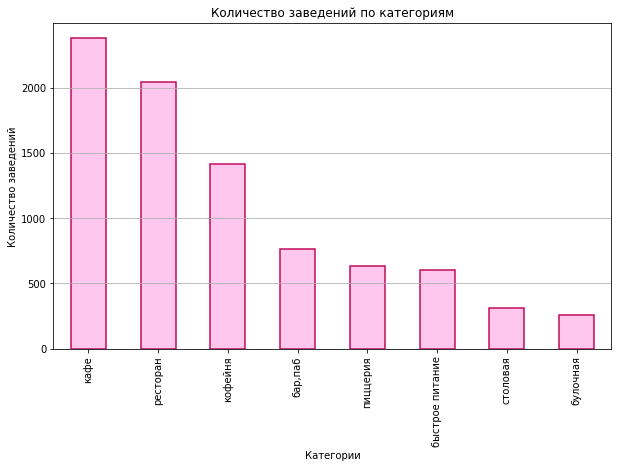

In [ ]:
category_counts = df['category'].value_counts()

plt.figure(figsize=(10, 6))
category_counts.plot(
    kind='bar',
    color='#ffc7ed',
    edgecolor='#c20858',
    linewidth=1.5,
    figsize=(10, 6)
)

plt.title('Количество зaведений по категориям')
plt.xlabel('Категории')
plt.ylabel('Количество заведений')
plt.grid(True, axis='y')
plt.show()

Больше всего оказалось кафе, немного остают рестораны. А вот булочных оказалось совсем мало- возможно стоит задуматься именно о таком формате.

---

### Задача 2

Изучим распределение завдений по районам.

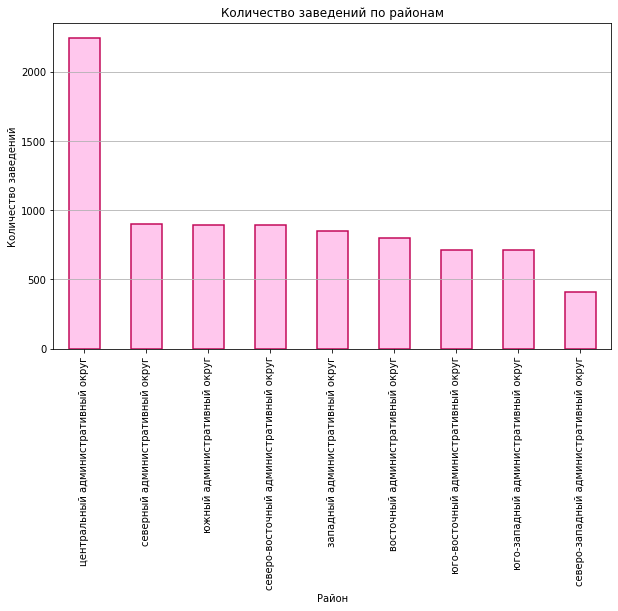

In [ ]:
dist_counts = df['district'].value_counts()

plt.figure(figsize=(10, 6))
dist_counts.plot(
    kind='bar',
    color='#ffc7ed',
    edgecolor='#c20858',
    linewidth=1.5,
    figsize=(10, 6)
)

plt.title('Количество зaведений по районам')
plt.xlabel('Район')
plt.ylabel('Количество заведений')
plt.grid(True, axis='y')
plt.show()

Ожидаемо, больше всего заведений в центре. В остальном в целом, количество заведений примерно одинаковое, только СЗАО чуть-чуть отстает. Посмотрим, каких заведений в центре больше всего.

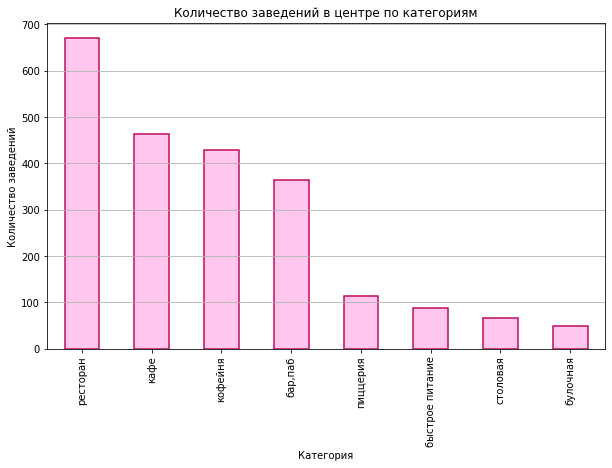

In [ ]:
center_counts = df[df['district']=='центральный административный округ']['category'].value_counts()

plt.figure(figsize=(10, 6))
center_counts.plot(
    kind='bar',
    color='#ffc7ed',
    edgecolor='#c20858',
    linewidth=1.5,
    figsize=(10, 6)
)

plt.title('Количество зaведений в центре по категориям')
plt.xlabel('Категория')
plt.ylabel('Количество заведений')
plt.grid(True, axis='y')
plt.show()

В отличие от общего распределения, в центре оказалось больше ресторанов, чем кафе. А вот булочных опять маловато.

---

### Задача 3


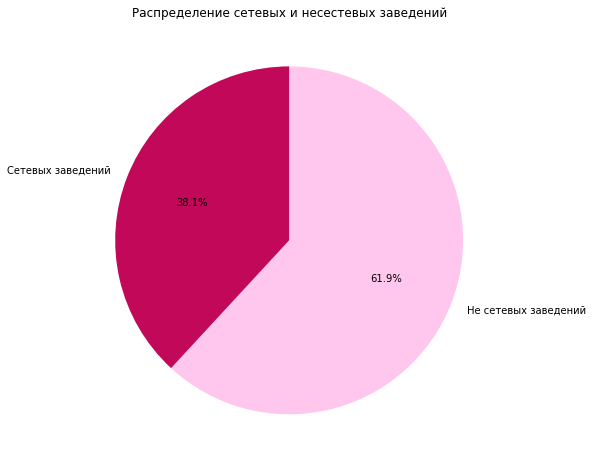

In [ ]:
palette = ['#ffc7ed', '#c20858', '#ff69b4', '#ff1493', '#db7093', '#c71585', '#ffb6c1', '#ad537a']

chain_counts = df['chain'].value_counts().rename(index={1: 'Сетевых заведений', 0: 'Не сетевых заведений'})

plt.figure(figsize=(8, 8))
plt.pie(chain_counts, labels=chain_counts.index, autopct='%1.1f%%', startangle=90, counterclock=False, colors=palette)
plt.title('Распределение сетевых и несестевых заведений')
plt.show()

Больше оказалось несетевых заведений, что логично- сложнее осуществлять работу целой сети, чем отдельного заведения. Посмотрим, какие заведения чаще становятся сетевыми.

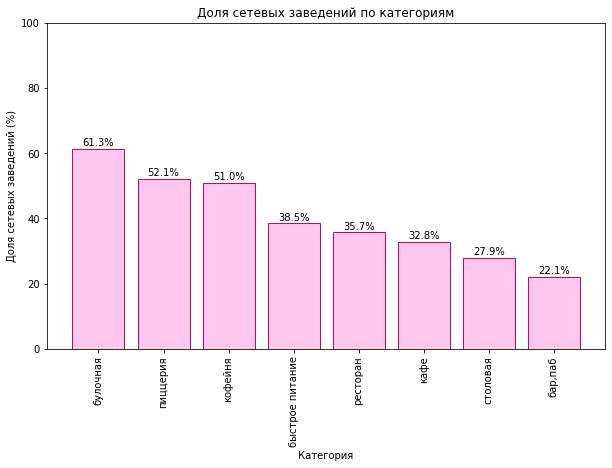

In [ ]:
chain_ratio = df.groupby('category').apply(lambda x: (x['chain'] == 1).sum() / len(x) * 100).reset_index(name='chain_share')
chain_ratio = chain_ratio.sort_values(by='chain_share', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(chain_ratio['category'], chain_ratio['chain_share'], color='#ffc7ed', edgecolor='#c20858')
plt.ylabel('Доля сетевых заведений (%)')
plt.xlabel('Категория')
plt.title('Доля сетевых заведений по категориям')
plt.ylim(0, 100)
plt.grid(False)
plt.xticks(rotation=90)

for index, value in enumerate(chain_ratio['chain_share']):
    plt.text(index, value + 1, f'{value:.1f}%', ha='center')

plt.show()

Больше всего сетевых заведений в категориях кафе, рестораны и кофейни. Реже всего сетями становятся столовые, но в целом отсальные категория тоже как сети существует совсем в небольшом количестве.

---

### Задача 4


In [ ]:
ano_max = df['seats'][df['seats'] != 0].max()
ano_min = df['seats'][df['seats'] != 0].min()
ano_med = df['seats'][df['seats'] != 0].quantile(0.5)
print(f"Максимальное значение: {ano_max}\nМинимальное значение: {ano_min}\nМедиана: {ano_med}")

Максимальное значение: 1288
Минимальное значение: 1
Медиана: 79.0


Судя по медиане и максимальному значению, в данных точно есть выбросы. Попробуем посмотреть 99% процентиль.

In [ ]:
per_99 = df['seats'].quantile(0.99)
print(f"99-процентиль: {per_99}")

99-процентиль: 625.0


99% всех данных меньше 490, значит только 1% данных превышает это значение. Посмотрим среднее количество посадчных мест по категориям с помощью ящика с усами и спрячем выбросы.

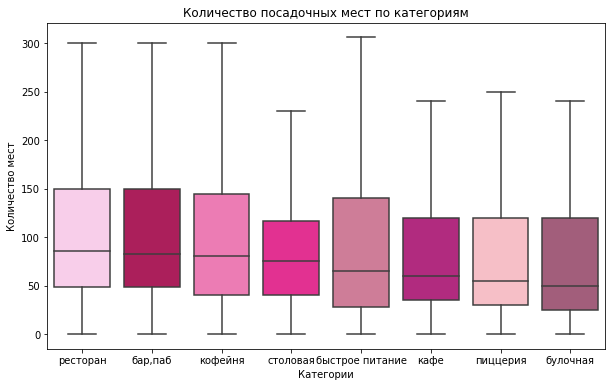

In [ ]:
df['category'] = pd.Categorical(df['category'], 
                                categories=df.groupby('category')['seats'].median().sort_values(ascending=False).index, 
                                ordered=True)

plt.figure(figsize=(10, 6))
sns.boxplot(x='category', y='seats', data=df, palette=palette, showfliers=False)

plt.title('Количество посадочных мест по категориям')
plt.xlabel('Категории')
plt.ylabel('Количество мест')
plt.grid(False)
plt.show()

Даже не смотря на то, что отображение выбросов отключено, медианы очень смещены (для всех категорий, кроме ресторанов и баров), что говорит о неравномерном распределении. Так же сами "ящики" довольно большие, значит большой разброс данных. Усы у всех ящиков длинные- много значений за пределами 75% квартиля, но не выбросы.

Попробуем посмотреть на распределение 75% (мне кажется, более информативно, чем смотреть на медианы в данном случае):

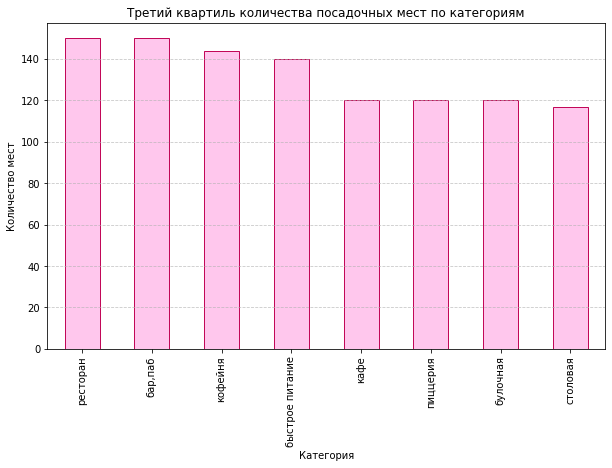

In [ ]:
perc_75 = df.groupby('category')['seats'].quantile(0.75)
perc_75 = perc_75.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
perc_75.plot(kind='bar', color='#ffc7ed', edgecolor='#c20858')

plt.title('Третий квартиль количества посадочных мест по категориям')
plt.xlabel('Категория')
plt.ylabel('Количество мест')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=90)

plt.show()

Получилось, что больше всего посадочных мест в ресторанах и барах, а меньше всего в кафе и булочных. В остальных категориях может сесть примерно одинаковое количество человек. 

---

### Задача 5


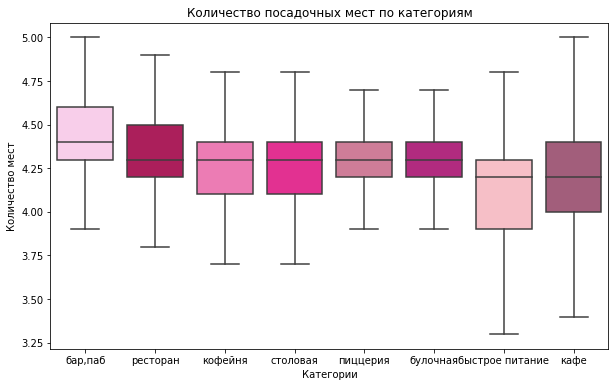

In [ ]:
median_order = df.groupby('category')['rating'].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))
sns.boxplot(x='category', y='rating', data=df, palette=palette, showfliers=False, order=median_order)

plt.title('Количество посадочных мест по категориям')
plt.xlabel('Категории')
plt.ylabel('Количество мест')
plt.grid(False)
plt.show()

Распределение рейтинга по категориям выглядит почти равномерным. Все категории в среднем поучают оценки от 4 до 5, но есть экстремально маленькие и большие оценки для каждой категории. Оценим средние знаечния:

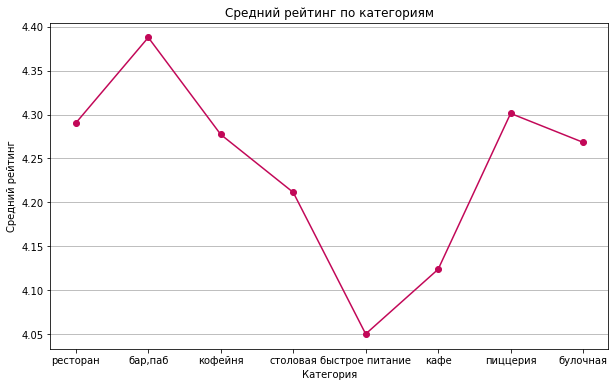

In [ ]:
mean_ratings = df.groupby('category')['rating'].mean()

plt.figure(figsize=(10, 6))
mean_ratings.plot(kind='line', 
                  marker='o', 
                  color='#c20858',
                  linewidth=1.5)

plt.title('Средний рейтинг по категориям')
plt.xlabel('Категория')
plt.ylabel('Средний рейтинг')
plt.grid(True, axis='y')
plt.show()

Самые низкие средние оценки у кафе и фастфуда, самые высокие- у баров. Интересно, что у пиццерий, кофейн, ресторанов, булочных и столовых одинаковые средние оценки. Это говорит о том, что оценки, в целом не зависят от категории заведения, а только от самих заведений. 

---

### Задача 6


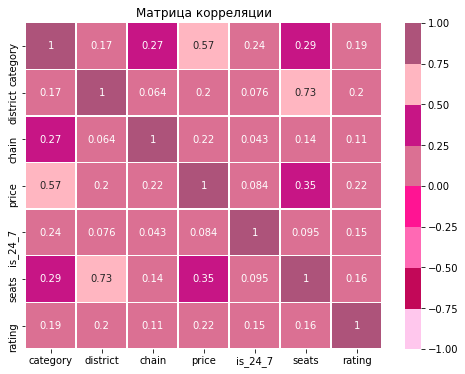

In [ ]:
phik_corr = df[['category', 'district', 'chain', 'price', 'is_24_7', 'seats', 'rating']].phik_matrix(interval_cols=['rating'])

plt.figure(figsize=(8, 6))
sns.heatmap(phik_corr, annot=True, cmap=palette, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Матрица корреляции')
plt.show()

Самая сильная корреляция между рейтингом и ценовой категорией. Еще довольно сильная корреляция с районом расположения и категорией заведения. Самая слабая- с тем круглосуточно работает заведение или нет. 

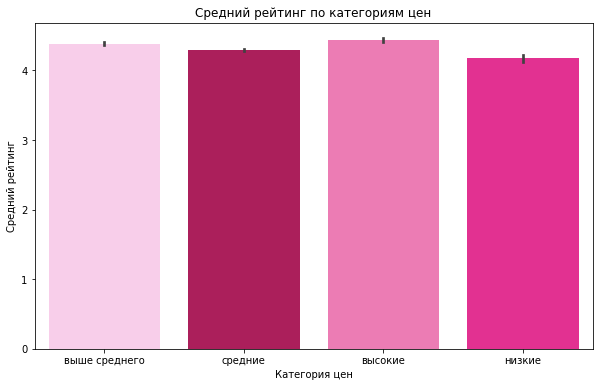

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='price', y='rating', data=df, palette=palette)

plt.title('Средний рейтинг по категориям цен')
plt.xlabel('Категория цен')
plt.ylabel('Средний рейтинг')
plt.grid(False)
plt.show()

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

In [ ]:
popular = (
    df.groupby('name')
    .agg(
        count=('name', 'count'),
        average_rating=('rating', 'mean'),
        category=('category', 'first')
    )
    .sort_values(by='count', ascending=False)
    .head(15)
)

popular['average_rating'] = popular['average_rating'].round(2)

print(popular)

                                     count  average_rating         category
name                                                                       
кафе                                   189            3.88             кафе
шоколадница                            120            4.18          кофейня
домино'с пицца                          77            4.17         пиццерия
додо пицца                              74            4.29         пиццерия
one price coffee                        72            4.07          кофейня
яндекс лавка                            69            3.87         ресторан
cofix                                   65            4.08          кофейня
prime                                   50            4.12         ресторан
хинкальная                              44            4.32  быстрое питание
шаурма                                  43            3.91  быстрое питание
кофепорт                                42            4.15          кофейня
кулинарная л

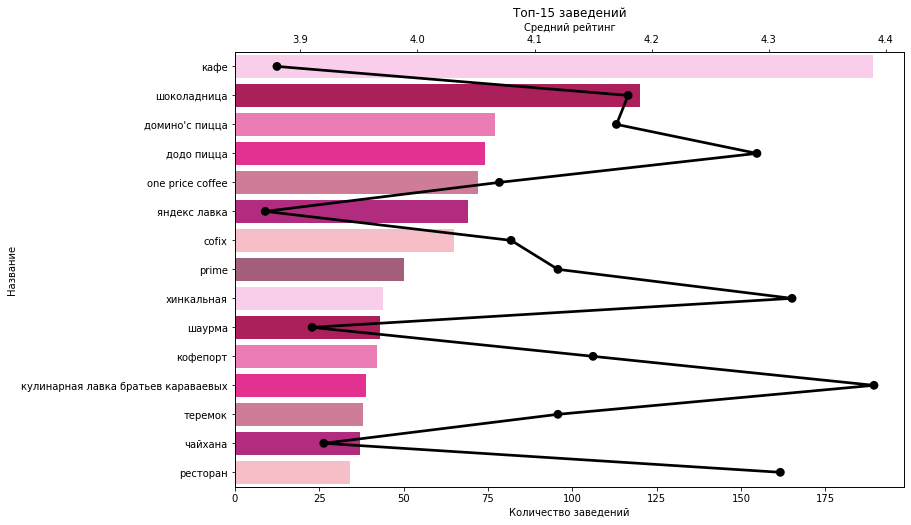

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 8))

sns.barplot(
    x='count', 
    y=popular.index, 
    data=popular, 
    palette=palette,
    ax=ax1
)
ax1.set_xlabel('Количество заведений')
ax1.set_ylabel('Название')

ax2 = ax1.twiny()
sns.pointplot(
    x='average_rating',
    y=popular.index,
    data=popular,
    color='black',
    ax=ax2
)
ax2.set_xlabel('Средний рейтинг')

plt.title('Топ-15 заведений')
plt.grid(False)
plt.show()

Черной линией на графике обозначен рейтинг, столбцами- количество заведений. Самое популярное заведение (кафе) имеет почти самый низкий рейтинг, такой же низкий только у яндекс лавки (на шестом месте). Самые высокие рейтинги у заведений с менее 75-ю филиалами.

---

### Задача 8



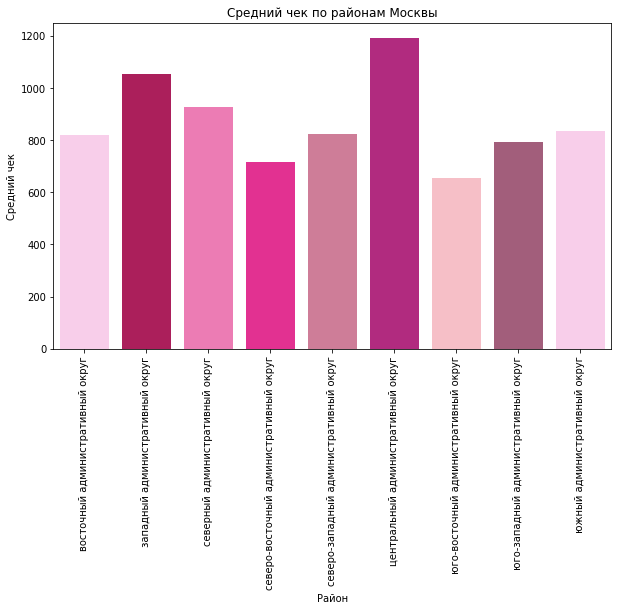

In [ ]:
avg_bill_by_district = df.groupby('district')['middle_avg_bill'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='district', y='middle_avg_bill', data=avg_bill_by_district, palette=palette)

plt.title('Средний чек по районам Москвы')
plt.xlabel('Район')
plt.ylabel('Средний чек')
plt.xticks(rotation=90)
plt.grid(False)
plt.show()

Самые большие значения у средних чеков, ожидаемо, в центре. На втором и третьем местах- ЗАО и САО. Самые низкие чеки в ЮВАО и СВАО.

## 4. Итоговый вывод и рекомендации

Самой распространенной категорией по всему городу оказались кафе, но в центре, где самый высокий средний чек, это рестораны. Чаще всего в сети перерастают кафе, рестораны и кофейни. А вот булочных по городу представлено довольно мало, возможно это как раз хорошая ниша в связи с низкой конкуренцией.

Количество посадочных мест не влияют ни на что и их количество зависит только от формата заведения- в ресторанах обычно много столов, а в булочных один-два.

Наибольшую (но совсем не большую, на самом деле) корреляцию с рейтингом показали ценовые категории. Но тут важно учитывать человеческий фактор- в более дорогих заведениях люди будут в среднем требовать более качественный сервис, а его отсутвие будет влиять на оценки куда сильнее, чем в фаст-фуд забегаловках.

При составлении топ-15 заведений лучший результат показала "Шоколадница"- не смотря на оцень большое количество заведений, средний их рейтинг выше чем у половины заведений.

Мои личные реккомендации: открывайте булочную в СЗАО- район с платежеспособными людьми, но заведений очень мало, а всяких ту-го кофеен три штуки и люди постоянно ходят со стаканчиками оттуда. Так что это вложение окупиться. Что точно не надо делать- открывать очередной реторан итальянской кухни в центре. Пинский с Истоминым открыли их столько, что теперь вся Москва не может есть пасту и угорает по русской кухне. Но чтобы выйти на окупаемость ресторана надо потратитьнесколько лет тщательного анализа потребителя, а в булочной или кофейне в правильном месте и наценкой на каждый стакан в 600%- за несколько месяцев.